# Client 1 Model (Split Federated Learning)

This notebook implements the client-side model for **Client 1** in a Split Federated Learning setup.
As per the system requirements:
1.  **Data:** Loaded locally from `datasets/Client1`.
2.  **Preprocessing:** Merges `patients`, `admissions`, `icustays` and extracts features.
3.  **Model:** A local PyTorch Encoder that outputs an intermediate vector.
4.  **Local Training:** Includes a temporary classifier head for local pretraining/debugging.

## 1. Import Dependencies

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from torch.utils.data import DataLoader


# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 2. Load  Data


 We will load this directly.

*File:* `data/processed/client1_processed.csv`

In [ ]:
import pickle
from sklearn.preprocessing import StandardScaler

# ── CONFIG ────────────────────────────────────────────────────────────────────
CLIENT_NAME = 'client1_surgical'   # change per client
BASE_PATH   = '/content/drive/MyDrive/Fockup Dataset MIMIC IV/MIMIC IV 3.1'

# ← Load RAW CSV
DATA_PATH   = f'{BASE_PATH}/fl_clients/{CLIENT_NAME}.csv'
MODEL_DIR   = f'{BASE_PATH}/fl_clients/models/{CLIENT_NAME}'
os.makedirs(MODEL_DIR, exist_ok=True)

print(f"Loading {CLIENT_NAME} (raw)...")
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")

# ── Separate features and label ───────────────────────────────────────────────
target_col = 'mortality'

# Vasopressor columns are binary — do NOT scale them
VASO_COLS  = ['vaso_dopamine','vaso_epinephrine','vaso_norepinephrine',
              'vaso_phenylephrine','vaso_vasopressin']

feature_cols = [c for c in df.columns if c != target_col]
scale_cols   = [c for c in feature_cols if c not in VASO_COLS]
vaso_present = [c for c in VASO_COLS if c in feature_cols]

X_all = df[feature_cols].values.astype(np.float32)
y     = df[target_col].values

print(f"Total features : {len(feature_cols)}")
print(f"  Scaled       : {len(scale_cols)}")
print(f"  Binary (vaso): {len(vaso_present)}")
print(f"Samples        : {len(y):,}")
print(f"Mortality rate : {y.mean()*100:.1f}%")

Loading client0_medical (raw)...
Shape: (36152, 267)
Total features : 266
  Scaled       : 261
  Binary (vaso): 5
Samples        : 36,152
Mortality rate : 16.1%


## 3. Train/Test Split (Local)

Even though this is a client in FL, we need to evaluate its *local* performance initially. We split the client's local data into train/val sets. This is standard practice before federated rounds begin.

In [ ]:
# ── STEP 2: Split FIRST, then scale ──────────────────────────────────────────
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_all, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # keeps mortality ratio equal in both sets
)

print(f"Train: {len(y_train):,} | Mortality: {y_train.mean()*100:.1f}%")
print(f"Val  : {len(y_val):,}   | Mortality: {y_val.mean()*100:.1f}%")

# ── STEP 3: Scale ONLY continuous features ────────────────────────────────────
# Get column positions
scale_idx = [feature_cols.index(c) for c in scale_cols]
vaso_idx  = [feature_cols.index(c) for c in vaso_present]

# Fit scaler on TRAINING DATA ONLY — never on val
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw[:, scale_idx])
X_val_scaled   = scaler.transform(X_val_raw[:, scale_idx])

# Clip extreme outliers (e.g. n_measured can be very large)
X_train_scaled = np.clip(X_train_scaled, -5, 5)
X_val_scaled   = np.clip(X_val_scaled,   -5, 5)

# Recombine scaled + binary vasopressors
if vaso_idx:
    X_train = np.hstack([X_train_scaled, X_train_raw[:, vaso_idx]])
    X_val   = np.hstack([X_val_scaled,   X_val_raw[:,   vaso_idx]])
else:
    X_train = X_train_scaled
    X_val   = X_val_scaled

# Save scaler for inference later
with open(f'{MODEL_DIR}/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print(f"\nX_train: {X_train.shape} | min={X_train.min():.2f} max={X_train.max():.2f}")
print(f"X_val  : {X_val.shape}   | min={X_val.min():.2f} max={X_val.max():.2f}")
print(f"Scaler saved ✓")

# ── STEP 4: Convert to tensors ────────────────────────────────────────────────
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train).reshape(-1, 1)
X_val_tensor   = torch.FloatTensor(X_val)
y_val_tensor   = torch.FloatTensor(y_val).reshape(-1, 1)

train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
val_dataset   = torch.utils.data.TensorDataset(X_val_tensor,   y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False)

print(f"\nTrain batches: {len(train_loader)}")
print(f"Val batches  : {len(val_loader)}")

Train: 28,921 | Mortality: 16.1%
Val  : 7,231   | Mortality: 16.1%

X_train: (28921, 266) | min=-5.00 max=5.00
X_val  : (7231, 266)   | min=-5.00 max=5.00
Scaler saved ✓

Train batches: 452
Val batches  : 113


## 4. Define Client Model Architecture

This is where the "Split" happens.
1.  **ClientEncoder:** Takes raw input -> Outputs `activation`. This `activation` is what gets sent to the server in a real SFL setup.
2.  **TemporaryClassifier:** Takes `activation` -> Output prediction. This is ONLY for local pre-training and validation.

In the real Split Federated Learning round, we only use `ClientEncoder`. The gradients come back from the server to update this encoder.

In [ ]:
class ClientEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super(ClientEncoder, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),   # 266 → 64
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.5),                    # stronger dropout
            nn.Linear(hidden_dim, hidden_dim // 2),  # 64 → 32
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.net(x)

class TemporaryClassifier(nn.Module):
    def __init__(self, input_dim):
        super(TemporaryClassifier, self).__init__()
        self.fc = nn.Linear(input_dim, 1)

    def forward(self, x):
        return self.fc(x)

class LocalModel(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(LocalModel, self).__init__()
        self.encoder    = ClientEncoder(input_dim, hidden_dim)
        self.classifier = TemporaryClassifier(hidden_dim // 2)

    def forward(self, x):
        return self.classifier(self.encoder(x))

input_dim  = X_train.shape[1]
hidden_dim = 64    # ← reduced from 128 to 64

local_model = LocalModel(input_dim, hidden_dim).to(device)

# pos_weight — cap at 5 to reduce focus on minority class
num_negative = (y_train == 0).sum()
num_positive = (y_train == 1).sum()
raw_weight   = num_negative / num_positive
pos_weight   = torch.tensor([min(raw_weight, 5.0)],
                              dtype=torch.float).to(device)

print(f"pos_weight : {pos_weight.item():.2f}  (capped at 5)")

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(local_model.parameters(),
                       lr=0.0001,
                       weight_decay=1e-3)   # ← stronger L2

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

# Count parameters
total_params = sum(p.numel() for p in local_model.parameters())
print(f"Total parameters : {total_params:,}")
print(f"Samples/param    : {len(X_train)/total_params:.2f}  (want > 5)")
print(local_model)

pos_weight : 5.00  (capped at 5)
Total parameters : 19,393
Samples/param    : 1.49  (want > 5)
LocalModel(
  (encoder): ClientEncoder(
    (net): Sequential(
      (0): Linear(in_features=266, out_features=64, bias=True)
      (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.5, inplace=False)
      (4): Linear(in_features=64, out_features=32, bias=True)
      (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
    )
  )
  (classifier): TemporaryClassifier(
    (fc): Linear(in_features=32, out_features=1, bias=True)
  )
)


## 5. Local Pre-Training Loop

We now train the `LocalModel` on Client 1's data. This ensures the `ClientEncoder` learns useful representations *before* connecting to the split server. This can significantly speed up the convergence of Split Federated Learning.

In [ ]:
num_epochs    = 80
best_val_loss = float('inf')
patience      = 8
patience_ctr  = 0
best_epoch    = 0
train_losses  = []
val_losses    = []

BEST_MODEL_PATH = f'{MODEL_DIR}/best.pth'

print("Starting Local Pre-training...")

for epoch in range(num_epochs):
    local_model.train()
    running_loss = 0.0
    for inputs, labels in tqdm(train_loader,
                               desc=f"Epoch {epoch+1}/{num_epochs}",
                               leave=False):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(local_model(inputs), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    local_model.eval()
    val_running_loss = 0.0
    correct = 0
    total   = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs        = local_model(inputs)
            val_running_loss += criterion(outputs, labels).item()
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            total    += labels.size(0)
            correct  += (predicted == labels).sum().item()

    avg_val_loss = val_running_loss / len(val_loader)
    accuracy     = 100 * correct / total
    val_losses.append(avg_val_loss)

    scheduler.step(avg_val_loss)

    print(f"Epoch [{epoch+1:>2}/{num_epochs}] | "
          f"Train: {avg_train_loss:.4f} | "
          f"Val: {avg_val_loss:.4f} | "
          f"Acc: {accuracy:.2f}%")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_epoch    = epoch + 1
        patience_ctr  = 0
        torch.save(local_model.state_dict(), BEST_MODEL_PATH)
        print(f"  ✓ Best: {best_val_loss:.4f}")
    else:
        patience_ctr += 1
        if patience_ctr >= patience:
            print(f"\nEarly stop at epoch {epoch+1}. "
                  f"Best epoch {best_epoch}: {best_val_loss:.4f}")
            break

local_model.load_state_dict(torch.load(BEST_MODEL_PATH))
print(f"\nLoaded best model from epoch {best_epoch}.")
encoder_only = local_model.encoder

Starting Local Pre-training...


Epoch [ 1/80] | Train: 0.8966 | Val: 0.7318 | Acc: 78.72%
  ✓ Best: 0.7318


Epoch [ 2/80] | Train: 0.6932 | Val: 0.6221 | Acc: 85.24%
  ✓ Best: 0.6221


Epoch [ 3/80] | Train: 0.6222 | Val: 0.5762 | Acc: 83.49%
  ✓ Best: 0.5762


Epoch [ 4/80] | Train: 0.5806 | Val: 0.5441 | Acc: 84.72%
  ✓ Best: 0.5441


...

Epoch [59/80] | Train: 0.4178 | Val: 0.4453 | Acc: 88.31%


Epoch [60/80] | Train: 0.4127 | Val: 0.4446 | Acc: 88.02%


Epoch [61/80] | Train: 0.4094 | Val: 0.4449 | Acc: 87.72%


Epoch [62/80] | Train: 0.4141 | Val: 0.4472 | Acc: 88.81%


Epoch [63/80] | Train: 0.4139 | Val: 0.4451 | Acc: 88.01%

Early stop at epoch 63. Best epoch 55: 0.4444

Loaded best model from epoch 55.


## 5b  Save the Encoder Weights
Right now your trained encoder only exists in RAM. If the kernel restarts, it's gone. Add this immediately after your training cell:

In [ ]:
# ← FIXED: all saves go to Google Drive
torch.save(local_model.state_dict(),
           f'{MODEL_DIR}/local_model.pth')

torch.save(local_model.encoder.state_dict(),
           f'{MODEL_DIR}/encoder.pth')

print(f"All files saved to: {MODEL_DIR}")
print(f"  best.pth          ← best checkpoint (saved during training)")
print(f"  encoder.pth       ← use this in SFL")
print(f"  local_model.pth   ← full model backup")
print(f"  scaler.pkl        ← saved in Cell 3")
print(f"Encoder output dim : {hidden_dim // 2}")
print(f"Encoder param count: {sum(p.numel() for p in local_model.encoder.parameters()):,}")

All files saved to: /content/drive/MyDrive/Fockup Dataset MIMIC IV/MIMIC IV 3.1/fl_clients/models/client0_medical
  best.pth          ← best checkpoint (saved during training)
  encoder.pth       ← use this in SFL
  local_model.pth   ← full model backup
  scaler.pkl        ← saved in Cell 3
Encoder output dim : 32
Encoder param count: 19,360


## 6. Detailed Evaluation
Calculate Confusion Matrix, Classification Report, and ROC-AUC to better evaluate the model performance.

Precision-Recall AUC: 0.8534


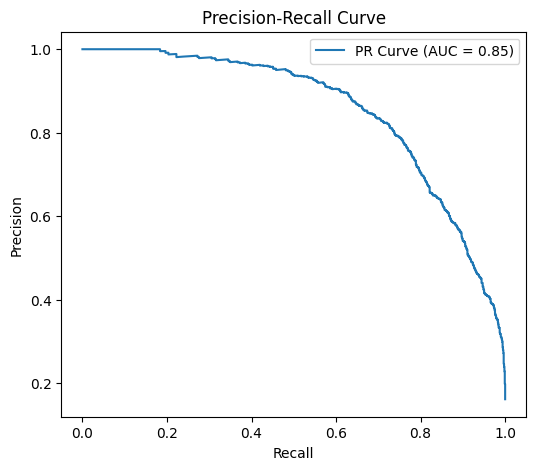

ROC-AUC Score: 0.9554
Optimal Threshold (max F1 for Expired): 0.7481


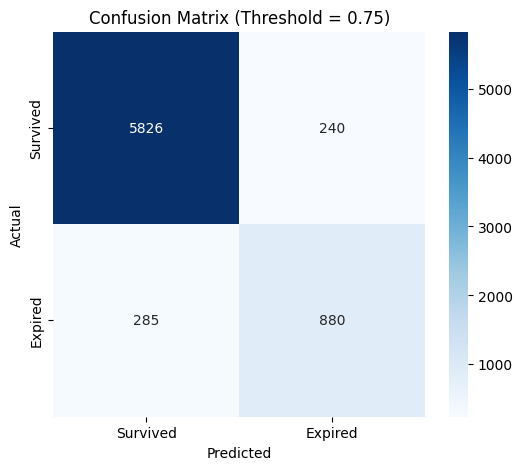


Classification Report:

              precision    recall  f1-score   support

    Survived       0.95      0.96      0.96      6066
     Expired       0.79      0.76      0.77      1165

    accuracy                           0.93      7231
   macro avg       0.87      0.86      0.86      7231
weighted avg       0.93      0.93      0.93      7231



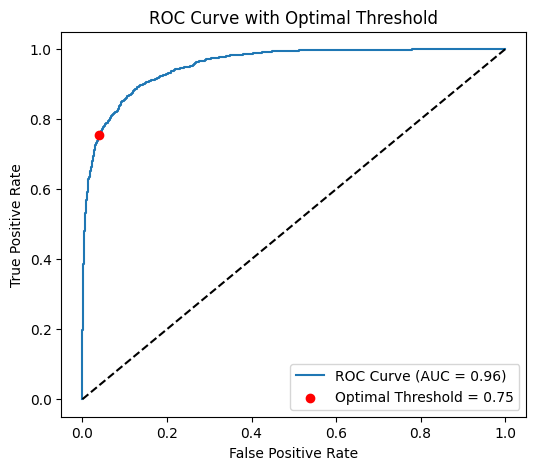

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, f1_score
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

local_model.eval()
all_probs = []
all_targets = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        logits = local_model(inputs)
        probs = torch.sigmoid(logits)  # Convert logits to probabilities
        all_probs.extend(probs.cpu().numpy())
        all_targets.extend(labels.cpu().numpy())

all_probs = np.array(all_probs).flatten()
all_targets = np.array(all_targets).flatten()

# -- Precision Recall --

precision_vals, recall_vals, pr_thresholds = precision_recall_curve(all_targets, all_probs)
pr_auc = average_precision_score(all_targets, all_probs)
print(f"Precision-Recall AUC: {pr_auc:.4f}")

plt.figure(figsize=(6, 5))
plt.plot(recall_vals, precision_vals, label=f'PR Curve (AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

# --- ROC-AUC ---
roc_auc = roc_auc_score(all_targets, all_probs)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# --- Find Optimal Threshold via F1 for Minority Class ---
fpr, tpr, thresholds = roc_curve(all_targets, all_probs)

f1_scores = []
for t in thresholds:
    preds = (all_probs >= t).astype(float)
    f1 = f1_score(all_targets, preds, pos_label=1, zero_division=0)
    f1_scores.append(f1)

optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
print(f"Optimal Threshold (max F1 for Expired): {optimal_threshold:.4f}")

# --- Final Predictions at Optimal Threshold ---
final_preds = (all_probs >= optimal_threshold).astype(float)

# --- Confusion Matrix ---
cm = confusion_matrix(all_targets, final_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Survived', 'Expired'],
            yticklabels=['Survived', 'Expired'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix (Threshold = {optimal_threshold:.2f})')
plt.show()

# --- Classification Report ---
print("\nClassification Report:\n")
print(classification_report(all_targets, final_preds, target_names=['Survived', 'Expired']))

# --- ROC Curve with Optimal Point Marked ---
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color='red',
            label=f'Optimal Threshold = {optimal_threshold:.2f}', zorder=5)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with Optimal Threshold')
plt.legend()
plt.show()

## 7. Simulate Split Learning Payload
To answer the question "Is it generating the correct activation vector?", we can simulate the "split" step.
We will take a single batch of data, pass it through the **Encoder only**, and inspect the output.
In the real Federated Learning setup, this `start_activations` tensor is exactly what gets sent to the server.

In [ ]:

# 1. Get a batch of data
client_data_loader = DataLoader(val_dataset, batch_size=5, shuffle=False)
data_iter = iter(client_data_loader)
inputs, labels = next(data_iter)
inputs = inputs.to(device)

# 2. Run ONLY the Client Encoder
encoder = local_model.encoder
encoder.eval()

with torch.no_grad():
    failed_attempts = 0 # Just for safety against network issues
    activations = encoder(inputs)


def get_activation_for_server(encoder, inputs):
    """
    Produces activation vector WITH gradient tracking.
    This is what you call in real SFL rounds — NOT inside torch.no_grad().
    The returned tensor must stay in memory until the server returns gradients.
    """
    encoder.train()  # Keep dropout active during federated training
    activations = encoder(inputs)  # requires_grad=True automatically since encoder params require grad
    return activations  # Shape: [batch_size, 64]

# Test it
sample_inputs, sample_labels = next(iter(train_loader))
sample_inputs = sample_inputs.to(device)

activations = get_activation_for_server(local_model.encoder, sample_inputs)

print(f"Activation shape: {activations.shape}")           # [64, 64]
print(f"Requires grad: {activations.requires_grad}")      # Must be True
print(f"Grad fn exists: {activations.grad_fn is not None}") # Must be True

print("--- Split Learning Simulation ---")
print(f"Input batch shape: {inputs.shape}")
print(f"Activation (smashed data) shape: {activations.shape}")
print(f"\nThis activation tensor of size {activations.size()} is what will be sent to the Server.")

print("\nSample of the first activation vector (first 20 values):")
print(activations[0, :20].detach().cpu().numpy())

# Verify we aren't sending the raw data
assert activations.shape[1] != inputs.shape[1], "Error: Activation shape matches input shape!"
print("\nSuccess: The activation dimension is different from the input dimension, meaning data is encoded.")

Activation shape: torch.Size([64, 32])
Requires grad: True
Grad fn exists: True
--- Split Learning Simulation ---
Input batch shape: torch.Size([5, 266])
Activation (smashed data) shape: torch.Size([64, 32])

This activation tensor of size torch.Size([64, 32]) is what will be sent to the Server.

Sample of the first activation vector (first 20 values):
[0.         0.         0.         0.         1.2091167  0.
 0.35520473 3.266382   0.         0.         0.         2.1151552
 0.         1.0117453  0.         0.         1.8025163  1.062023
 1.9925369  0.        ]

Success: The activation dimension is different from the input dimension, meaning data is encoded.
